In [1]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import savemat
sys.path.append(os.path.abspath(".."))

from toolbox_mingyang import *

f = h5py.File("../data/SimuData.mat", "r")
print(list(f.keys()))


['Image', 'Magnitude', 'Phase']


(4, 8, 256, 256)


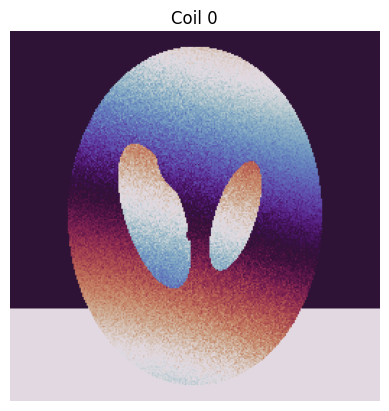

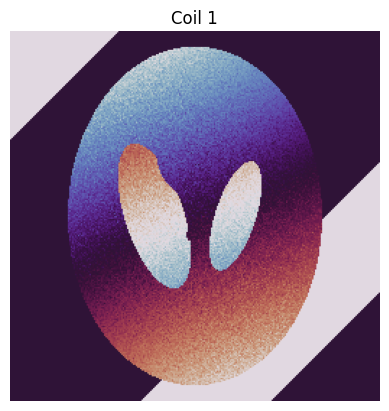

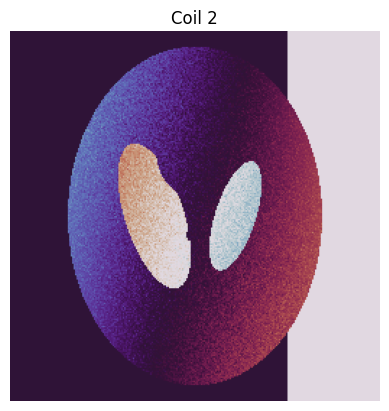

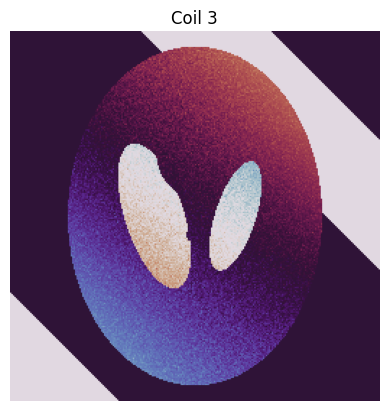

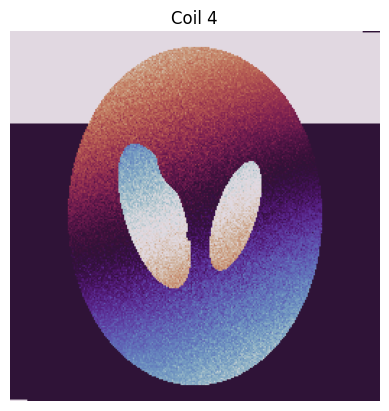

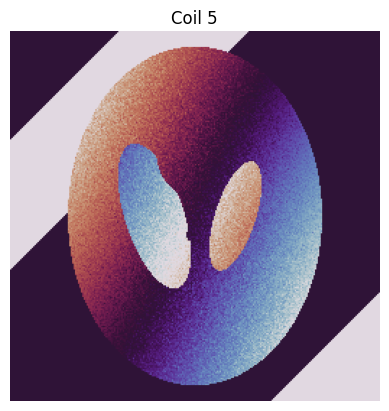

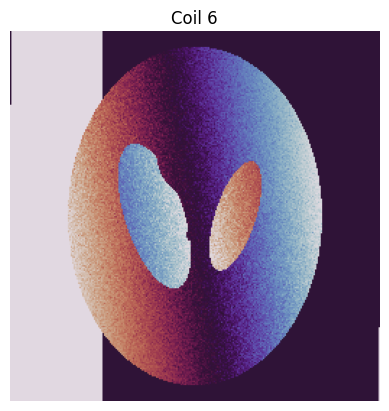

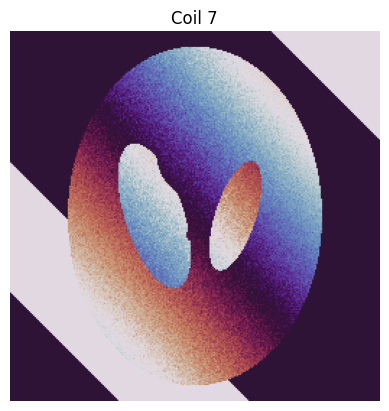

In [2]:
Mag = f["Magnitude"][:]
Phase = f["Phase"][:]

Nsh, Npe, Nro = Phase.shape

CSM_tmp = simulate_coils(Nro, Npe, 8)
Phase_real = Phase['real']

img = Mag * np.exp(1j * Phase_real)

img_exp = img[:, None, :, :]
CSM_exp = CSM_tmp[None, :, :, :]

ImageData = img_exp * CSM_exp

savemat("../data/ImageData.mat", {"ImageData": ImageData})

print(ImageData.shape)
for i in range(8):
    show_mri(ImageData[1][i], "phase",title=f"Coil {i}")